# Figure 5
## Correlation plots from FANTOM5 datasets
### Author: Martin Loza
### Date: 25/12/30

Let's plot the combined results from different FANTOM5 datasets

In [1]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
    library(dplyr)
    library(ggvenn)
    library(ComplexHeatmap)
    library(circlize)
})

# Local variables 
seed = 777
date = "251230"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
gray = "gray50"

text_size = 18
width = 18.6
height = 5
dot_size = 4
line_size = 1.5
dpi = 300

fantom_coexpression_results = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/09_FANTOM5_time_course_analyses/Results/Coexpression_results/"
out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/10_Figure_5/Results/"
plots_out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/10_Figure_5/Results/Plots/"
tables_out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Supplementary/"
# Local Functions



### Load and setup the data

In [2]:
datasets <- c("Lymphatic", "Aortic", "MCF7", "Monocyte-derived", "Saos-2")

data_list <- lapply(datasets, function(dataset) {
    # Load data
    data_file <- paste0(fantom_coexpression_results, dataset, "_coexpression_results_251230.tsv")
    data <- read.table(data_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
    data$Dataset <- dataset
    return(data)
})

head(data_list[[1]])

,gene_pair_id,lncRNA_gene_id,TF_gene_id,n_samples,pearson_correlation,pearson_pvalue,pearson_fdr,spearman_correlation,spearman_pvalue,spearman_fdr,Dataset
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,ENSG00000227640_ENSG00000125285,ENSG00000227640_94712716,ENSG00000125285_94712545,0,NA,NA,NA,NA,NA,NA,Lymphatic
2,ENSG00000263146_ENSG00000256463,ENSG00000263146_78979074,ENSG00000256463_78979818,0,NA,NA,NA,NA,NA,NA,Lymphatic
3,ENSG00000277268_ENSG00000273706,ENSG00000277268_36936670,ENSG00000273706_36936784,0,NA,NA,NA,NA,NA,NA,Lymphatic
4,ENSG00000236502_ENSG00000138083,ENSG00000236502_44941582,ENSG00000138083_44941702,0,NA,NA,NA,NA,NA,NA,Lymphatic
5,ENSG00000255399_ENSG00000089225,ENSG00000255399_114408426,ENSG00000089225_114408442,0,NA,NA,NA,NA,NA,NA,Lymphatic
6,ENSG00000240990_ENSG00000005073,ENSG00000240990_27185235,ENSG00000005073_27185232,16,1,0,0,1,0,0,Lymphatic


Load the gene_pairs original information to recover gene annotations

In [3]:
gene_pairs_file = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Annotated_ncRNA_PCG_pairs/human_unique_lncRNA_TF_pairs_10000bp_251215.tsv"
gene_pairs <- read.table(gene_pairs_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
cat("Number of gene pairs: ", nrow(gene_pairs), "\n")
cat("Any duplicates in gene_pair_id: ", any(duplicated(gene_pairs$gene_pair_id)), "\n")
head(gene_pairs)

Number of gene pairs:  1978 
Any duplicates in gene_pair_id:  FALSE 


,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,⋯,Family,is_TF,abs_strand_distance,ncrna_gene_id,pcg_gene_id,gene_pair_id,gene_name_pair_id,ncrna_is_mane,tf_is_mane,mane_priority
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<lgl>,<int>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>
1,11,ENST00000381363,2140644,IGF2-AS,1,lncRNA,ENST00000643349,unnamed,2149603,8959,⋯,ZBTB,TRUE,8959,ENSG00000099869,ENSG00000284779,ENSG00000099869_ENSG00000284779,IGF2-AS_unnamed,FALSE,FALSE,4
2,11,ENST00000833483,61756482,MYRF-AS1,-1,lncRNA,ENST00000265460,MYRF,61755389,-1093,⋯,NDT80_PhoG,TRUE,1093,ENSG00000124915,ENSG00000124920,ENSG00000124915_ENSG00000124920,MYRF-AS1_MYRF,FALSE,FALSE,4
3,2,ENST00000440903,222302978,CCDC140,1,lncRNA,ENST00000392070,PAX3,222298998,-3980,⋯,PAX,TRUE,3980,ENSG00000163081,ENSG00000135903,ENSG00000163081_ENSG00000135903,CCDC140_PAX3,FALSE,TRUE,2
4,17,ENST00000738117,76562607,SNHG16,1,lncRNA,ENST00000713548,unnamed,76569648,7041,⋯,ZBTB,TRUE,7041,ENSG00000163597,ENSG00000284526,ENSG00000163597_ENSG00000284526,SNHG16_unnamed,FALSE,TRUE,2
5,5,ENST00000809704,136132805,SMAD5-AS1,-1,lncRNA,ENST00000545279,SMAD5,136132845,40,⋯,MH1,TRUE,40,ENSG00000164621,ENSG00000113658,ENSG00000164621_ENSG00000113658,SMAD5-AS1_SMAD5,FALSE,TRUE,2
6,10,ENST00000625168,45000920,ZNF22-AS1,-1,lncRNA,ENST00000298299,ZNF22,45000923,3,⋯,zf-C2H2,TRUE,3,ENSG00000165511,ENSG00000165512,ENSG00000165511_ENSG00000165512,ZNF22-AS1_ZNF22,FALSE,TRUE,2


Let's also load the ranked pairs for comparison with ENCODE and GTEx 

In [4]:
ranked_gene_pairs_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Supplementary/"
# Load the ranked gene pairs
gene_pairs_ranked = read.table(paste0(ranked_gene_pairs_dir, "Supplementary_table_ranked_lncRNA_TF_gene_pairs_251218.tsv"),
                        sep = "\t", header = TRUE, stringsAsFactors = FALSE)
head(gene_pairs_ranked,3)
nrow(gene_pairs_ranked)

,gene_pair_id,gene_name_pair_id,lncRNA_Family,avg_correlation,overall_rank,is_DT,is_AS
,<chr>,<chr>,<chr>,<dbl>,<int>,<lgl>,<lgl>
1,ENSG00000227640_ENSG00000125285,SOX21-AS1_SOX21,HMG,0.9682961,1,FALSE,TRUE
2,ENSG00000263146_ENSG00000256463,LINC01896_SALL3,zf-C2H2,0.9499586,2,FALSE,FALSE
3,ENSG00000277268_ENSG00000273706,LHX1-DT_LHX1,Homeobox,0.9465009,3,TRUE,FALSE


[1] 260

Let's merge the coexpression results across datasets

In [5]:
# Combine all datasets into a single data frame
coexpression_fantom <- Reduce(rbind, data_list)
cat("Number of coexpression entries before filtering: ", nrow(coexpression_fantom), "\n")
# Let's remove gene pairs that have NA correlation in all datasets
coexpression_fantom <- coexpression_fantom %>%
    group_by(gene_pair_id) %>% 
    filter(!all(is.na(pearson_correlation)) & !all(is.na(spearman_correlation))) %>%
    ungroup()
cat("Number of coexpression entries after filtering: ", nrow(coexpression_fantom), "\n")

Number of coexpression entries before filtering:  1300 


Number of coexpression entries after filtering:  375 


Let's transfer some original annotations

In [6]:
# Transfer relevant annotation columns to the coexpression results
sel_cols <- c('ncrna_tss','pcg_tss','Family','abs_strand_distance','gene_pair_id','gene_name_pair_id')
coexpression_fantom_ann <- coexpression_fantom %>%
    left_join(gene_pairs[, sel_cols], by = "gene_pair_id")

# Transfer ranking information
sel_cols <- c('gene_pair_id','avg_correlation','overall_rank','is_DT','is_AS')
coexpression_fantom_ann <- coexpression_fantom_ann %>%
    left_join(gene_pairs_ranked[, sel_cols], by = "gene_pair_id")

In [7]:
coexpression_fantom_ann %>% filter(!duplicated(gene_pair_id)) %>% nrow()

[1] 75

### Analysis

Let's select significant gene pairs within each dataset

In [8]:
# Select significant pairs based on adjusted p-value
adjusted_pvalue_threshold <- 0.05
selected_fantom <- coexpression_fantom_ann %>%
    filter(pearson_fdr <= adjusted_pvalue_threshold & spearman_fdr <= adjusted_pvalue_threshold)

cat("Number of significant gene pairs in FANTOM: ", nrow(selected_fantom), "\n")

Number of significant gene pairs in FANTOM:  116 


In [9]:
cat("Number of unique gene pairs with pearson correlation of 1: ", 
    n_distinct(selected_fantom$gene_pair_id[selected_fantom$pearson_correlation == 1]), "\n")
cat("Number of unique gene pairs with pearson correlation different from 1: ", 
    n_distinct(selected_fantom$gene_pair_id[selected_fantom$pearson_correlation != 1]), "\n")

Number of unique gene pairs with pearson correlation of 1:  39 
Number of unique gene pairs with pearson correlation different from 1:  12 


Add the number of datasets for each gene_pair

In [10]:
# Add the number of datasets where each gene pair is significant
selected_fantom <- selected_fantom %>%
    group_by(gene_pair_id) %>%
    mutate(num_datasets_significant = n_distinct(Dataset)) %>%
    ungroup()

We have many coexpressing pairs that have a perfect correlation, this is most likely because they overlap with the same CAGE TSSs cluster, e.g. their TSS is less than 100 bps. While these pairs are biologically interesting, to investigate the real dynamics we would prefer the ones with no perfect correlation, e.g. to create dynamical plots

In [11]:
selected_fantom %>% filter(!duplicated(gene_pair_id)) %>% nrow 

[1] 48

In [12]:
# Let's save the selected significant gene pairs for further analysis
write.table(selected_fantom,
            file = paste0(out_dir, "selected_significant_gene_pairs_FANTOM_4_plotting_", date, ".tsv"), 
            sep = "\t", quote = FALSE, row.names = FALSE)

#### Pearson vs Spearman correlation in FANTOM datasets

Let's visualize the relationship between Pearson and Spearman correlations for gene pairs, summarized across datasets

In [13]:
# Aggregate correlation values per gene_pair_id
fantom_summary <- selected_fantom %>%
    group_by(gene_pair_id) %>%
    summarise(
        avg_pearson = mean(pearson_correlation, na.rm = TRUE),
        avg_spearman = mean(spearman_correlation, na.rm = TRUE),
        n_datasets = first(num_datasets_significant),
        Family = first(Family),
        gene_name_pair_id = first(gene_name_pair_id)
    ) %>%
    ungroup()

cat("Number of unique gene pairs: ", nrow(fantom_summary), "\n")
cat("Distribution of n_datasets:\n")
table(fantom_summary$n_datasets)

Number of unique gene pairs:  48 


Distribution of n_datasets:



 1  2  3  4  5 
24  6  3  4 11 

Warning message in annotate("label", x = 0.5, y = 0.95, label = paste0("R = ", cor_r, :
“Ignoring unknown parameters: `label.size`”
`geom_smooth()` using formula = 'y ~ x'


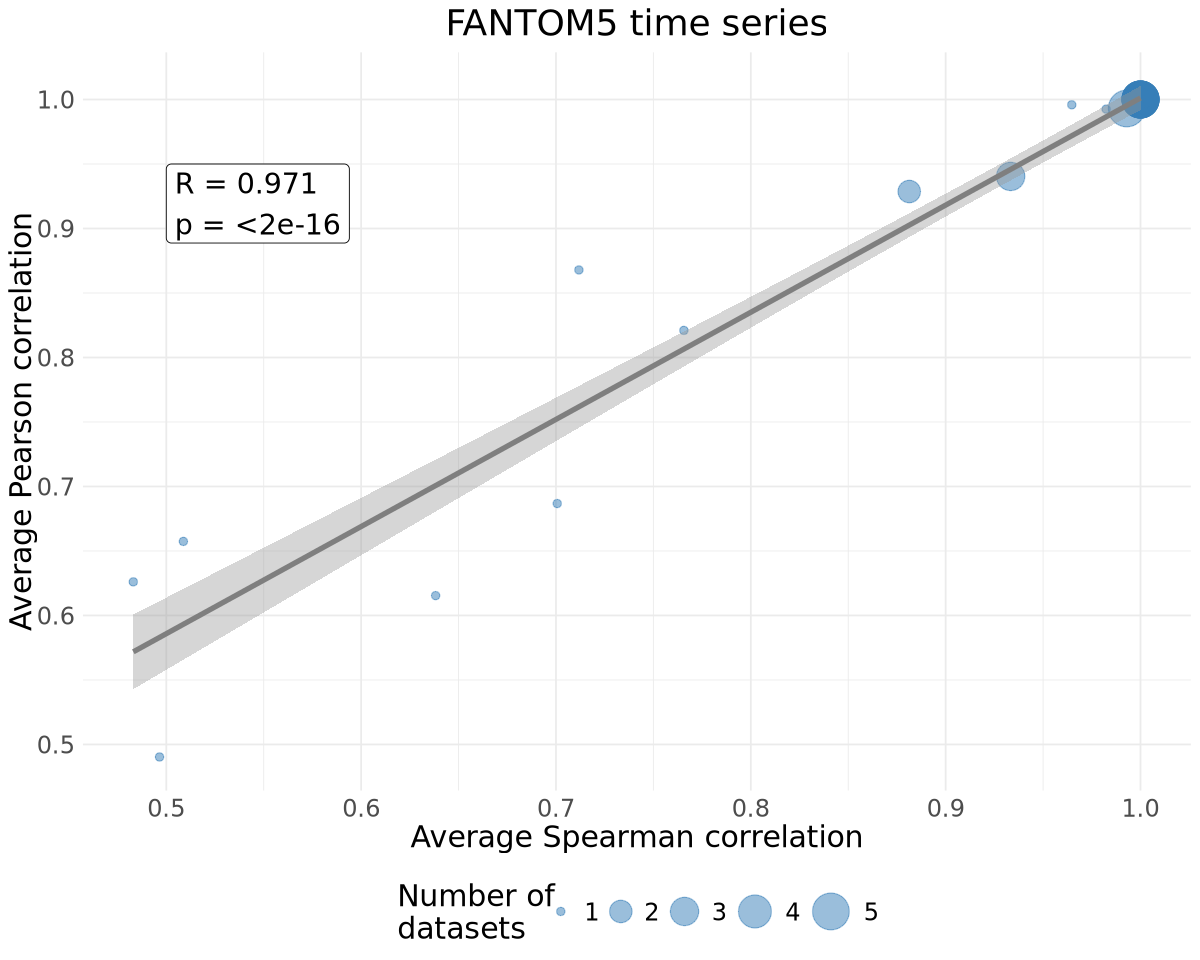

In [14]:
# Create scatter plot comparing Pearson vs Spearman correlations
# Calculate correlation statistics between methods
cor_test_methods <- cor.test(fantom_summary$avg_pearson, fantom_summary$avg_spearman, method = "pearson")
cor_r <- round(cor_test_methods$estimate, 3)
cor_p <- format.pval(cor_test_methods$p.value, digits = 2)

# Create the plot
p_pearson_spearman <- ggplot(fantom_summary, aes(x = avg_spearman, y = avg_pearson, size = n_datasets)) +
     geom_point(color = blue, alpha = 0.5) +
     geom_smooth(inherit.aes = FALSE, aes(x = avg_spearman, y = avg_pearson),
                    method = "lm", color = gray, linewidth = line_size, se = TRUE, show.legend = FALSE) +
     scale_size_continuous(name = "Number of\ndatasets", range = c(2, 10), breaks = c(1, 2, 3, 4, 5)) +
     annotate("label", x = 0.5, y = 0.95, 
                label = paste0("R = ", cor_r, "\np = ", cor_p),
                hjust = 0, vjust = 1, size = 6,
                fill = "white", color = "black", label.size = 0.5) +
     labs(x = "Average Spearman correlation", 
           y = "Average Pearson correlation",
           title = "FANTOM5 time series") +
     theme_minimal() +
     theme(text = element_text(size = text_size),
            strip.text = element_text(size = text_size + 1),
            plot.title = element_text(hjust = 0.5),
            legend.position = "bottom")

# Display the plot
options(repr.plot.width=10, repr.plot.height=8)
print(p_pearson_spearman)

In [15]:
# Save the plot
ggsave(filename = paste0(out_dir, "Pearson_vs_Spearman_FANTOM_", date, ".pdf"),
       plot = p_pearson_spearman,
       width = width * 0.3, height = height, dpi = dpi)

`geom_smooth()` using formula = 'y ~ x'


Let's now compare the averaged FANTOM correlation with the average correlation obtained from ENCODE and GTEx analyses.

In [16]:
# Transfer ENCODE/GTEx avg_correlation and overall_rank to fantom_summary
fantom_summary <- fantom_summary %>%
    left_join(gene_pairs_ranked %>% select(gene_pair_id, avg_correlation), 
              by = "gene_pair_id") %>%
              dplyr::rename(avg_correlation_encode_gtex = avg_correlation)
head(fantom_summary,3)

gene_pair_id,avg_pearson,avg_spearman,n_datasets,Family,gene_name_pair_id,avg_correlation_encode_gtex
<chr>,<dbl>,<dbl>,<int>,<chr>,<chr>,<dbl>
ENSG00000176593_ENSG00000166704,0.9286514,0.8813209,2,zf-C2H2,ZNF606-AS1_ZNF606,0.8498259
ENSG00000177133_ENSG00000142611,1.0000000,1.0000000,1,zf-C2H2,PRDM16-DT_PRDM16,0.8352639
ENSG00000213888_ENSG00000100105,0.6153948,0.6382353,1,ZBTB,LINC01521_PATZ1,0.6006815


Number of gene pairs for comparison:  48 


Warning message in annotate("label", x = 0.5, y = 0.7, label = paste0("R = ", cor_r_pearson, :
“Ignoring unknown parameters: `label.size`”
Warning message in annotate("label", x = 0.5, y = 0.7, label = paste0("R = ", cor_r_spearman, :
“Ignoring unknown parameters: `label.size`”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthet

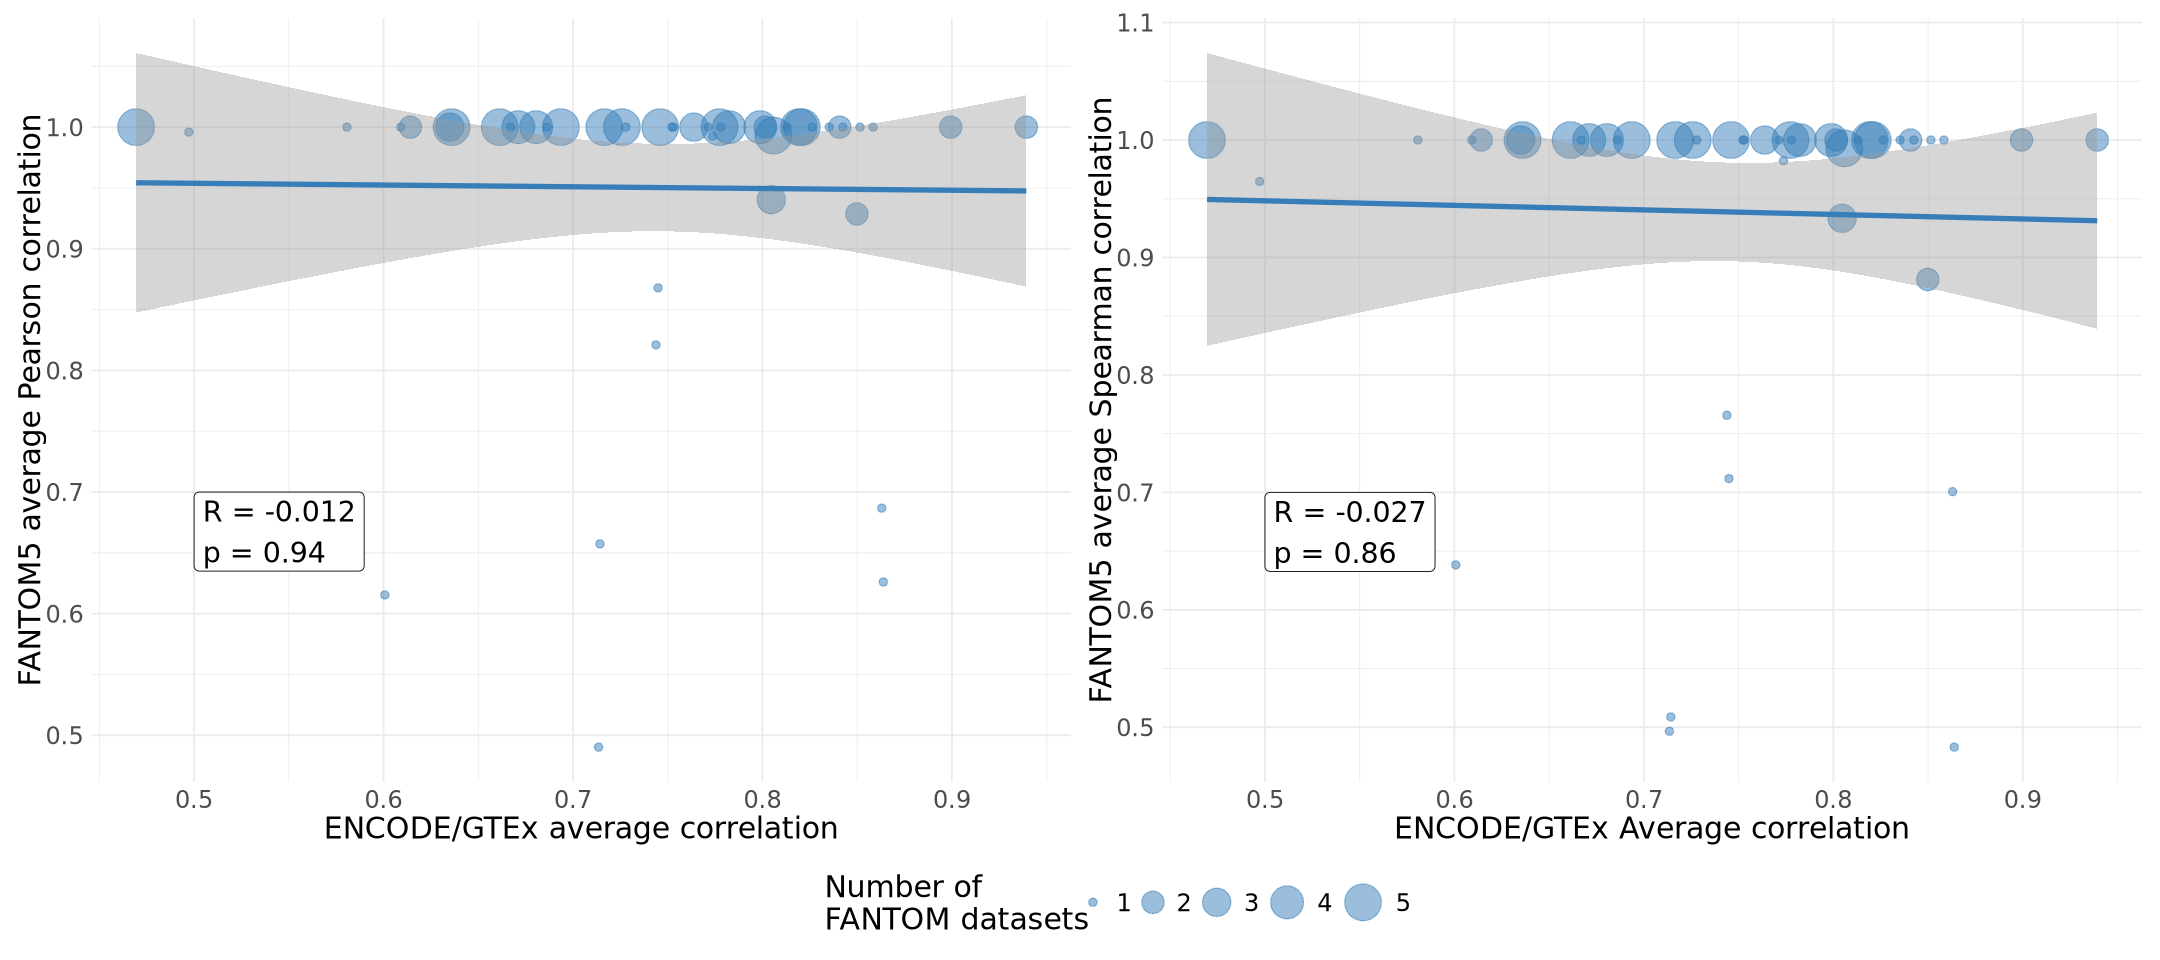

In [17]:
# Create scatter plots comparing FANTOM correlations vs ENCODE/GTEx average correlation
# Filter to only gene pairs that have both FANTOM and ENCODE/GTEx data
fantom_encode_gtex_comparison <- fantom_summary %>%
    filter(!is.na(avg_correlation_encode_gtex))

cat("Number of gene pairs for comparison: ", nrow(fantom_encode_gtex_comparison), "\n")

# Calculate correlation statistics for Pearson
cor_test_pearson <- cor.test(fantom_encode_gtex_comparison$avg_correlation_encode_gtex, 
                              fantom_encode_gtex_comparison$avg_pearson, 
                              method = "pearson")
cor_r_pearson <- round(cor_test_pearson$estimate, 3)
cor_p_pearson <- format.pval(cor_test_pearson$p.value, digits = 2)

# Calculate correlation statistics for Spearman
cor_test_spearman <- cor.test(fantom_encode_gtex_comparison$avg_correlation_encode_gtex, 
                               fantom_encode_gtex_comparison$avg_spearman, 
                               method = "pearson")
cor_r_spearman <- round(cor_test_spearman$estimate, 3)
cor_p_spearman <- format.pval(cor_test_spearman$p.value, digits = 2)

# Create the Pearson comparison plot
p_fantom_pearson_vs_encode_gtex <- ggplot(
    fantom_encode_gtex_comparison,
    aes(x = avg_correlation_encode_gtex, y = avg_pearson, size = n_datasets)
) +
    geom_point(color = blue, alpha = 0.5) +
    geom_smooth(method = "lm", color = blue, linewidth = line_size,
                se = TRUE, show.legend = FALSE) +
    scale_size_continuous(name = "Number of\nFANTOM datasets",
                          range = c(2, 10), breaks = c(1, 2, 3, 4, 5)) +
    annotate("label", x = 0.5, y = 0.7,
             label = paste0("R = ", cor_r_pearson, "\np = ", cor_p_pearson),
             hjust = 0, vjust = 1, size = 6,
             fill = "white", color = "black", label.size = 0.5) +
    labs(x = "ENCODE/GTEx average correlation",
         y = "FANTOM5 average Pearson correlation") +
    theme_minimal() +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          plot.title = element_text(hjust = 0.5),
          legend.position = "bottom")

# Create the Spearman comparison plot
p_fantom_spearman_vs_encode_gtex <- ggplot(
    fantom_encode_gtex_comparison,
    aes(x = avg_correlation_encode_gtex, y = avg_spearman, size = n_datasets)
) +
    geom_point(color = blue, alpha = 0.5) +
    geom_smooth(method = "lm", color = blue, linewidth = line_size,
                se = TRUE, show.legend = FALSE) +
    scale_size_continuous(name = "Number of\nFANTOM datasets",
                          range = c(2, 10), breaks = c(1, 2, 3, 4, 5)) +
    annotate("label", x = 0.5, y = 0.7,
             label = paste0("R = ", cor_r_spearman, "\np = ", cor_p_spearman),
             hjust = 0, vjust = 1, size = 6,
             fill = "white", color = "black", label.size = 0.5) +
    labs(x = "ENCODE/GTEx Average correlation",
         y = "FANTOM5 average Spearman correlation") +
    theme_minimal() +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          plot.title = element_text(hjust = 0.5),
          legend.position = "bottom")

# Combine both plots
p_fantom_vs_encode_gtex <- (p_fantom_pearson_vs_encode_gtex | p_fantom_spearman_vs_encode_gtex) + plot_layout(
    guides = "collect"
  ) & theme(
    legend.position = "bottom"
  )

# Display the combined plot
options(repr.plot.width=18, repr.plot.height=8)
print(p_fantom_vs_encode_gtex)

In [18]:
# Save the combined plot
ggsave(filename = paste0(out_dir, "Supplementary_FANTOM_vs_ENCODE_GTEx_comparison_", date, ".pdf"),
       plot = p_fantom_vs_encode_gtex,
       width = width * 0.9, height = height+1, dpi = dpi)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


### Pearson transformed across FANTOM datasets

Then, let's focus on the Pearson correlation. We would like to stabilize the variance using the Fisher z-transformation to ease comparison across datasets

In [19]:
# Apply Fisher z-transformation to stabilize variance of correlation coefficients
# First, adjust correlations to avoid infinite values (subtract small value from perfect correlations)
# Fisher z-transformation: z = 0.5 * log((1+r)/(1-r))
selected_fantom <- selected_fantom %>%
    mutate(
        # Adjust correlations by subtracting 0.001 to avoid perfect 1.0 values
        pearson_adjusted = pmin(pearson_correlation - 0.001, 0.999),
        # Apply Fisher z-transformation
        pearson_fisher_z = 0.5 * log((1 + pearson_adjusted) / (1 - pearson_adjusted))
    )

# Check for infinite values (should be zero now)
cat("Number of infinite values in pearson_fisher_z: ", sum(is.infinite(selected_fantom$pearson_fisher_z)), "\n")
cat("Range of pearson_fisher_z: ", range(selected_fantom$pearson_fisher_z, na.rm = TRUE), "\n")

head(selected_fantom %>% select(gene_pair_id, Dataset, pearson_correlation, pearson_adjusted, pearson_fisher_z), 10)

Number of infinite values in pearson_fisher_z:  0 
Range of pearson_fisher_z:  0.5351255 3.800201 


gene_pair_id,Dataset,pearson_correlation,pearson_adjusted,pearson_fisher_z
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ENSG00000240990_ENSG00000005073,Lymphatic,1,0.999,3.800201
ENSG00000230844_ENSG00000251192,Lymphatic,1,0.999,3.800201
ENSG00000225733_ENSG00000177463,Lymphatic,1,0.999,3.800201
ENSG00000283122_ENSG00000118495,Lymphatic,1,0.999,3.800201
ENSG00000269834_ENSG00000167555,Lymphatic,1,0.999,3.800201
ENSG00000267886_ENSG00000183850,Lymphatic,1,0.999,3.800201
ENSG00000273329_ENSG00000106459,Lymphatic,1,0.999,3.800201
ENSG00000232104_ENSG00000080298,Lymphatic,1,0.999,3.800201
ENSG00000268362_ENSG00000213096,Lymphatic,1,0.999,3.800201


#### Heatmap of Pearson correlations across FANTOM datasets

Let's create a heatmap to visualize how gene pairs correlate across different cell types

In [20]:
# Prepare data for heatmap: reshape to wide format
# Include ALL significant gene pairs (even those in only 1 dataset)
gene_pairs_multi_dataset <- selected_fantom

cat("Total number of entries: ", nrow(gene_pairs_multi_dataset), "\n")
cat("Number of unique gene pairs: ", n_distinct(gene_pairs_multi_dataset$gene_pair_id), "\n")

# Create wide format with Fisher z-transformed Pearson correlations
heatmap_data <- gene_pairs_multi_dataset %>%
    select(gene_pair_id, Dataset, pearson_fisher_z, gene_name_pair_id) %>%
    tidyr::pivot_wider(
        id_cols = c(gene_pair_id, gene_name_pair_id),
        names_from = Dataset,
        values_from = pearson_fisher_z
    )

cat("Heatmap data dimensions: ", dim(heatmap_data), "\n")
head(heatmap_data, 3)

Total number of entries:  116 
Number of unique gene pairs:  48 


Heatmap data dimensions:  48 7 


gene_pair_id,gene_name_pair_id,Lymphatic,Aortic,MCF7,Monocyte-derived,Saos-2
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000240990_ENSG00000005073,HOXA11-AS_HOXA11,3.800201,NA,NA,NA,3.800201
ENSG00000230844_ENSG00000251192,ZNF674-AS1_ZNF674,3.800201,NA,NA,NA,3.800201
ENSG00000225733_ENSG00000177463,FGD5-AS1_NR2C2,3.800201,3.800201,3.800201,3.800201,3.800201


In [21]:
# Prepare matrix for heatmap
heatmap_matrix <- heatmap_data %>%
    select(-gene_pair_id, -gene_name_pair_id) %>%
    as.matrix()

rownames(heatmap_matrix) <- heatmap_data$gene_name_pair_id

# Replace infinite values with NA for better visualization
heatmap_matrix[is.infinite(heatmap_matrix)] <- NA

# Calculate number of datasets (non-NA values) for each gene pair
non_na_counts <- rowSums(!is.na(heatmap_matrix))

# Calculate average Fisher z score for ranking
avg_fisher_z <- rowMeans(heatmap_matrix, na.rm = TRUE)

# Select top 50 pairs by absolute average Fisher z score
top_indices <- order(abs(avg_fisher_z), decreasing = TRUE)[1:min(50, length(avg_fisher_z))]
heatmap_matrix_top <- heatmap_matrix[top_indices, ]
non_na_counts_top <- non_na_counts[top_indices]

# Arrange rows by number of datasets (descending), then by absolute average Fisher z
order_indices <- order(-non_na_counts_top, -abs(rowMeans(heatmap_matrix_top, na.rm = TRUE)))
heatmap_matrix_top <- heatmap_matrix_top[order_indices, ]

cat("Heatmap matrix dimensions (top pairs): ", dim(heatmap_matrix_top), "\n")
cat("Distribution of datasets in top pairs:\n")
print(table(rowSums(!is.na(heatmap_matrix_top))))

Heatmap matrix dimensions (top pairs):  48 5 
Distribution of datasets in top pairs:

 1  2  3  4  5 
24  6  3  4 11 


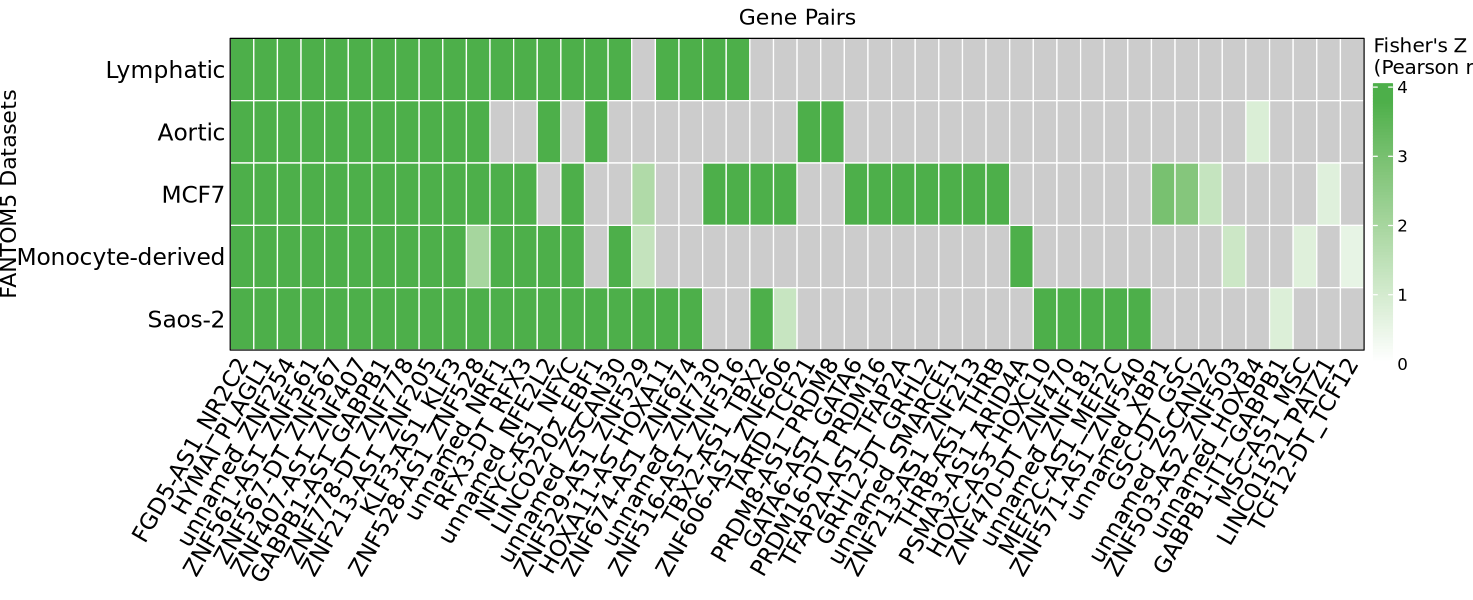

In [22]:
# Create heatmap using ComplexHeatmap

# Define color palette
col_fun <- colorRamp2(
    c( 0, max(abs(heatmap_matrix_top), na.rm = TRUE)),
    c("white", green)
)
# Transpose the matrix to swap rows and columns
heatmap_matrix_rot <- t(heatmap_matrix_top)

# Create the heatmap with rotated orientation (datasets as rows, gene pairs as columns)
p_heatmap <- Heatmap(
    heatmap_matrix_rot,
    name = "Fisher's Z",
    col = col_fun,
    na_col = "gray80",
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    show_row_names = TRUE,
    show_column_names = TRUE,
    row_names_gp = gpar(fontsize = text_size - 4),
    column_names_gp = gpar(fontsize = text_size - 4),
    column_names_rot = 60,
    row_names_side = "left",
    column_title = "Gene Pairs",
    row_title = "FANTOM5 Datasets",
    heatmap_legend_param = list(
        title = "Fisher's Z\n(Pearson r)",
        title_gp = gpar(fontsize = 12),
        labels_gp = gpar(fontsize = 10),
        legend_direction = "vertical",
        legend_height = unit(6, "cm")
    ),
    border = TRUE,
    rect_gp = gpar(col = "white", lwd = 1),
    width = unit(ncol(heatmap_matrix_rot) * 0.5, "cm")
)

# Display the plot
options(repr.plot.width=width*0.66, repr.plot.height=height)
draw(p_heatmap, heatmap_legend_side = "right")

In [23]:
# Save the heatmap
pdf(paste0(out_dir, "Heatmap_correlations_across_FANTOM_datasets_", date, ".pdf"),
    width = width*0.69, height = height*1)
draw(p_heatmap, heatmap_legend_side = "right")
dev.off()

pdf 
  2

Interestingly, even it was not significant in the adjusted pvalue of Spearman correlation, there was one gene pair with negative correlation that was significant in the Pearson correlation

It was the GATA3-AS1_GATA3

It might be interesting to add it to Supplementary

In [24]:
coexpression_fantom_ann %>%
    filter(pearson_fdr <= 0.05 & pearson_correlation < 0) %>% 
    arrange(pearson_correlation) %>% 
    select(gene_name_pair_id, pearson_correlation, spearman_correlation, pearson_fdr, spearman_fdr)

gene_name_pair_id,pearson_correlation,spearman_correlation,pearson_fdr,spearman_fdr
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
GATA3-AS1_GATA3,-0.6059998,-0.5117647,0.02206563,0.07579967
